# **Exploratory Factor Analysis (EFA)**
### **Dimensi Service Quality Bank ABC**
**Analisis Data dan Statistik - Kelompok 5**  
Bonifasius Argyanto (23426002)  
Aulya Az Zaafirrahman (23426014)  
Gibran Juniansyah (23426702)  
M Aqilla Khalafazka S (23426709)  
Luthfi Nur Muharram (23426711)  

## Impor Modul dan Setup Dataset

```bash
pip install factor_analyzer pingouin pandas numpy matplotlib openpyxl
```

In [141]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from factor_analyzer import FactorAnalyzer, calculate_kmo, calculate_bartlett_sphericity
import pingouin as pg

pd.set_option('display.float_format', lambda x: f'{x:0.3f}')
np.set_printoptions(suppress=True)

In [142]:
# input data
FILE_PATH = "Data-EFA-Servqual-2026.xlsx"

codebook = pd.read_excel(FILE_PATH, sheet_name="Codebook")
df = pd.read_excel(FILE_PATH, sheet_name="Data")

# hanya ambil kolom item
item_cols = [c for c in df.columns if c.startswith("X")]
data = df[item_cols].copy()

print(data.shape)
data.head()

(500, 30)


,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X21,X22,X23,X24,X25,X26,X27,X28,X29,X30
0,6,5,6,5,6,6,7,6,5,5,...,7,4,5,6,7,7,5,7,5,4
1,5,4,5,6,5,7,5,5,4,5,...,5,4,5,5,5,6,6,4,4,5
2,5,5,5,5,7,4,4,5,5,3,...,4,5,3,6,6,6,5,3,4,3
3,4,4,3,5,5,4,3,4,5,5,...,2,4,2,4,3,4,4,4,4,3
4,5,5,5,5,6,5,6,5,5,6,...,4,6,3,5,4,6,4,4,4,4


## Helper functions
Fungsi yang digunakan untuk tiap step (uji kelayakan, anti image, ekstraksi faktor, komunalitas, rotasi, loading, reliabilitas, dan pelabelan faktor)

In [ ]:
def kmo_bartlett_report(data_subset):
    """Uji kelayakan data: KMO overall + Bartlett's test SAJA (bukan MSA per item)."""
    _, kmo_overall = calculate_kmo(data_subset)
    chi2, p = calculate_bartlett_sphericity(data_subset)

    # print(f"KMO overall        : {kmo_overall:.3f}  (>0.6 layak difaktorkan)")
    # print(f"Bartlett chi-square : {chi2:.2f}")
    # print(f"Bartlett p-value    : {p:.4g}  (<0.05 berarti data layak)")

    return pd.Series(
        {"KMO_overall": kmo_overall, "Bartlett_chi2": chi2, "Bartlett_p": p},
        name="kelayakan_data",
    )


def msa_diagonal_antiimage(data_subset):
    """MSA (Measure of Sampling Adequacy) tiap item, dari diagonal anti-image
    correlation matrix (kmo_per_var). Independen dari kmo_bartlett_report, tidak print apa-apa."""
    kmo_per_var, _ = calculate_kmo(data_subset)
    msa_df = pd.DataFrame({"item": data_subset.columns, "MSA": kmo_per_var})
    msa_df = msa_df.sort_values("MSA")

    return msa_df


def scree_and_eigen(data_subset, n_factors_show=None):
    """Ekstraksi awal (unrotated) + eigenvalues + scree plot."""
    fa = FactorAnalyzer(rotation=None, n_factors=data_subset.shape[1])
    fa.fit(data_subset)
    ev, _ = fa.get_eigenvalues()

    n = n_factors_show or len(ev)
    plt.figure(figsize=(7, 4))
    plt.plot(range(1, n + 1), ev[:n], "o-")
    plt.axhline(1, color="red", linestyle="--", label="eigenvalue = 1 (Kaiser)")
    plt.xlabel("Faktor ke-")
    plt.ylabel("Eigenvalue")
    plt.title("Scree Plot")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    n_kaiser = int((ev > 1).sum())
    print(f"Jumlah faktor eigenvalue > 1 (Kaiser): {n_kaiser}")
    return ev


def communalities(data_subset, n_factors):
    """Komunalitas tiap item pada ekstraksi n_factors."""
    fa = FactorAnalyzer(n_factors=n_factors, rotation=None)
    fa.fit(data_subset)
    comm = pd.DataFrame({"item": data_subset.columns, "communality": fa.get_communalities()})
    return comm.sort_values("communality")


def run_efa(data_subset, n_factors, rotation="promax"):
    """
    Ekstraksi + rotasi.
    rotation: 'promax' / 'oblimin' (oblique) atau 'varimax' (orthogonal) untuk pembanding.
    Return: fa object, loadings df, factor-correlation (phi) kalau oblique.
    """
    fa = FactorAnalyzer(n_factors=n_factors, rotation=rotation)
    fa.fit(data_subset)

    loadings = pd.DataFrame(
        fa.loadings_,
        index=data_subset.columns,
        columns=[f"Faktor{i+1}" for i in range(n_factors)],
    )

    phi = None
    if rotation in ("promax", "oblimin"):
        phi = pd.DataFrame(
            fa.phi_,
            index=loadings.columns,
            columns=loadings.columns,
        )

    return fa, loadings, phi


def flag_cross_and_low_loadings(loadings, primary_threshold=0.40, cross_gap=0.20):
    """
    Bantu identifikasi kandidat item bermasalah utk purifikasi:
    - loading tertinggi < primary_threshold berarti item lemah, kandidat buang
    - selisih loading tertinggi vs kedua-tertinggi < cross_gap berarti cross-loading, kandidat buang
    """
    abs_l = loadings.abs()
    sorted_vals = abs_l.apply(lambda row: sorted(row, reverse=True), axis=1)

    report = pd.DataFrame(index=loadings.index)
    report["top_loading"] = sorted_vals.apply(lambda x: x[0])
    report["second_loading"] = sorted_vals.apply(lambda x: x[1])
    report["gap"] = report["top_loading"] - report["second_loading"]
    report["primary_factor"] = abs_l.idxmax(axis=1)
    report["flag_low"] = report["top_loading"] < primary_threshold
    report["flag_cross"] = report["gap"] < cross_gap

    return report.sort_values(["flag_low", "flag_cross"], ascending=False)


def variance_explained(fa_model, n_factors):
    """
    Proportion & Cumulative variance explained tiap faktor (setelah rotasi).
    fa_model: objek FactorAnalyzer yang sudah di-fit.
    """
    ss_loadings, prop_var, cum_var = fa_model.get_factor_variance()

    df = pd.DataFrame({
        "Faktor": [f"Faktor{i+1}" for i in range(n_factors)],
        "SS Loadings": ss_loadings.round(3),
        "Proportion Var": (prop_var * 100).round(2),
        "Cumulative Var (%)": (cum_var * 100).round(2),
    })
    return df


def cronbach_by_factor(data_subset, loadings, primary_threshold=0.40):
    """Cronbach's Alpha per dimensi, berdasarkan primary factor tiap item."""
    abs_l = loadings.abs()
    primary = abs_l.idxmax(axis=1)
    primary = primary[abs_l.max(axis=1) >= primary_threshold]  # buang yang loadingnya lemah

    results = []
    for factor in sorted(primary.unique()):
        items = primary[primary == factor].index.tolist()
        if len(items) < 2:
            results.append({"factor": factor, "n_items": len(items), "items": items, "alpha": None})
            continue
        alpha = pg.cronbach_alpha(data=data_subset[items])[0]
        results.append({"factor": factor, "n_items": len(items), "items": items, "alpha": alpha})

    return pd.DataFrame(results)


def top_items_per_factor(loadings, codebook_df, top_n=5, primary_threshold=0.40):
    abs_l = loadings.abs()
    primary_factor = abs_l.idxmax(axis=1)  # faktor dgn loading tertinggi tiap item

    out = {}
    for factor in loadings.columns:
        members = loadings.index[(primary_factor == factor) & (abs_l[factor] >= primary_threshold)]
        top = loadings.loc[members, factor].abs().sort_values(ascending=False).head(top_n)
        items = top.index.tolist()
        text = codebook_df.set_index("Kode Item").loc[items, "Pernyataan Kuesioner (Skala 1-7)"]
        out[factor] = pd.DataFrame({"loading": top.values, "pernyataan": text.values}, index=items)

    return out


def alpha_if_item_deleted(data_subset, items):
    """
    Untuk tiap item dalam faktor, hitung alpha SELURUH item (baseline)
    vs alpha kalau item itu dihapus dari faktor.
    Delta positif = alpha NAIK kalau item dibuang (item agak melemahkan faktor).
    Delta negatif = alpha TURUN kalau item dibuang (item penting, jangan dibuang).
    """
    baseline_alpha = pg.cronbach_alpha(data=data_subset[items])[0]

    rows = []
    for item in items:
        remaining = [i for i in items if i != item]
        alpha_without = pg.cronbach_alpha(data=data_subset[remaining])[0]
        rows.append({
            "item": item,
            "alpha_full": round(baseline_alpha, 3),
            "alpha_if_deleted": round(alpha_without, 3),
            "delta": round(alpha_without - baseline_alpha, 3),
        })

    return pd.DataFrame(rows).sort_values("delta", ascending=False)


def anti_image_correlation_matrix(data_subset):
    """
    Anti-image correlation matrix lengkap.
    Off-diagonal = korelasi parsial antar item (idealnya kecil/mendekati 0).
    Diagonal = MSA per item (diisi dari calculate_kmo biar konsisten).
    """
    corr = data_subset.corr().values
    inv_corr = np.linalg.inv(corr)
    d = np.sqrt(np.diag(inv_corr))
    aic = -inv_corr / np.outer(d, d)

    msa_per_var, _ = calculate_kmo(data_subset)
    np.fill_diagonal(aic, msa_per_var)

    return pd.DataFrame(aic, index=data_subset.columns, columns=data_subset.columns)

---
## 1. Uji Kelayakan Data (KMO & Bartlett)
Apakah 30 item ini emang punya struktur korelasi yang "layak" difaktorkan?  
KMO harus > 0.6, Bartlett harus < 0.05

In [144]:
active_items = item_cols.copy()

kmo_report = kmo_bartlett_report(data[active_items])
kmo_report

KMO_overall        0.896
Bartlett_chi2   5051.708
Bartlett_p         0.000
Name: kelayakan_data, dtype: float64

## 2. Anti-Image Correlation / MSA
Seberapa besar varians item tertentu yang bisa dijelaskan oleh item-item lain melalui faktor bersama, dibanding varians yang hanya noise-nya sendiri  
Semakin besar MSA semakin baik yang menandakan semakin kecil korelasi parsial  
MSA harus di atas treshold umum yakni > 0.5. Jika semua di atasnya maka cek item dengan skor terbawah (bisa jadi kandidat yg dapat dibuang jika divalidasi pengecekan berikutnya)

In [145]:
msa_df = msa_diagonal_antiimage(data[active_items])
msa_df

,item,MSA
16,X17,0.746
19,X20,0.768
10,X11,0.769
3,X4,0.786
18,X19,0.808
7,X8,0.832
17,X18,0.840
13,X14,0.843
14,X15,0.857
4,X5,0.869


## 3. Ekstraksi Faktor Awal & Komunalitas
Komunalitas = berapa persen variansnya yang berhasil dijelaskan oleh faktor-faktor yang diekstrak, digabung semua faktor  
Treshold umum komunalitas > 0.3-0.4

In [146]:
comm_df = communalities(data[active_items], n_factors=5)
comm_df

,item,communality
16,X17,0.064
10,X11,0.072
19,X20,0.077
3,X4,0.083
18,X19,0.121
29,X30,0.409
28,X29,0.426
27,X28,0.431
21,X22,0.431
11,X12,0.449


## 4. Penentuan Jumlah Faktor
Bandingkan: (a) eigenvalue > 1 (Kaiser), (b) scree plot (cari elbow point), (c) teori a priori (5 dimensi SERVQUAL).

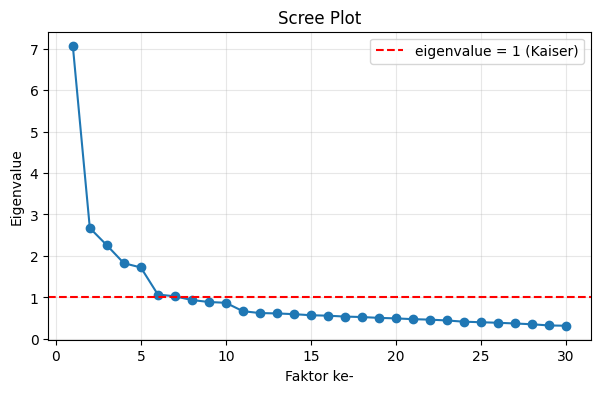

Jumlah faktor eigenvalue > 1 (Kaiser): 7


In [147]:
eigenvalues = scree_and_eigen(data[active_items])

## 5. Rotasi Faktor
Oblique (Promax) sebagai utama karena dimensi service quality secara konsep saling berkorelasi. Varimax sebagai pembanding.

In [148]:
N_FACTORS = 5 

fa_promax, loadings_promax, phi_promax = run_efa(data[active_items], N_FACTORS, rotation="promax")
loadings_promax.round(3)

,Faktor1,Faktor2,Faktor3,Faktor4,Faktor5
X1,-0.091,0.762,-0.042,-0.033,0.130
X2,0.776,-0.023,0.017,0.065,-0.070
X3,-0.029,-0.036,0.765,0.004,0.076
X4,0.018,0.008,0.294,-0.043,-0.050
X5,-0.014,0.020,0.036,0.696,0.010
X6,0.474,0.440,0.005,-0.031,-0.064
X7,0.445,-0.062,0.347,0.020,0.067
X8,0.011,-0.106,-0.015,0.714,0.090
X9,-0.034,0.395,-0.053,0.523,0.007
X10,-0.101,0.040,0.048,0.006,0.695


In [149]:
# Factor correlation matrix (phi) - korelasi antar faktor > ~0.3
phi_promax.round(3)

,Faktor1,Faktor2,Faktor3,Faktor4,Faktor5
Faktor1,1.000,0.197,0.404,0.475,0.393
Faktor2,0.197,1.000,0.287,0.223,0.389
Faktor3,0.404,0.287,1.000,0.248,0.483
Faktor4,0.475,0.223,0.248,1.000,0.289
Faktor5,0.393,0.389,0.483,0.289,1.000


In [150]:
# Pembanding: Varimax (orthogonal)
fa_varimax, loadings_varimax, _ = run_efa(data[active_items], N_FACTORS, rotation="varimax")
loadings_varimax.round(3)

,Faktor1,Faktor2,Faktor3,Faktor4,Faktor5
X1,0.066,0.125,0.695,0.113,0.185
X2,0.717,0.153,0.111,0.109,0.114
X3,0.121,0.718,0.137,0.098,0.130
X4,0.056,0.274,0.061,-0.007,-0.021
X5,0.044,0.117,0.143,0.685,0.074
X6,0.506,0.182,0.476,0.081,0.094
X7,0.487,0.404,0.100,0.088,0.190
X8,0.056,0.054,0.030,0.682,0.139
X9,0.061,0.095,0.440,0.576,0.087
X10,0.081,0.101,0.107,0.080,0.652


## 6. Purifikasi Item Iteratif
Flag low menandakan loading di bawah treshold, patut dibuang karena minim kontribusi ke faktor  
Flag cross menandakan loading gap dua faktor di bawah treshold, tunggu drop flag low dulu karena bisa jadi efek cemaran ke faktor. Jika masih terindikasi maka patut dibuang bertahap

In [151]:
problem_report = flag_cross_and_low_loadings(loadings_promax, primary_threshold=0.40, cross_gap=0.20)
problem_report

,top_loading,second_loading,gap,primary_factor,flag_low,flag_cross
X11,0.270,0.071,0.198,Faktor2,True,True
X17,0.229,0.081,0.148,Faktor1,True,True
X4,0.294,0.050,0.244,Faktor3,True,False
X19,0.333,0.053,0.279,Faktor5,True,False
X20,0.266,0.051,0.215,Faktor4,True,False
X6,0.474,0.440,0.034,Faktor1,False,True
X7,0.445,0.347,0.098,Faktor1,False,True
X9,0.523,0.395,0.128,Faktor4,False,True
X23,0.435,0.422,0.012,Faktor2,False,True
X28,0.424,0.303,0.121,Faktor1,False,True


In [152]:
# Iterasi 1: buang item flag_low (MSA rendah + komunalitas rendah + loading lemah, 3 bukti sepakat)
dropped_log = []
dropped_log.append({"item": "X4",  "iterasi": 1, "alasan": "MSA rendah (0.786), komunalitas sangat rendah (0.083), loading tertinggi 0.294 (<0.40)"})
dropped_log.append({"item": "X11", "iterasi": 1, "alasan": "MSA rendah (0.769), komunalitas sangat rendah (0.072), loading tertinggi 0.270"})
dropped_log.append({"item": "X17", "iterasi": 1, "alasan": "MSA terendah (0.746), komunalitas terendah (0.064), loading tertinggi 0.229"})
dropped_log.append({"item": "X19", "iterasi": 1, "alasan": "MSA rendah (0.808), komunalitas rendah (0.121), loading tertinggi 0.333"})
dropped_log.append({"item": "X20", "iterasi": 1, "alasan": "MSA rendah (0.768), komunalitas rendah (0.077), loading tertinggi 0.266"})

active_items_iter1 = [c for c in active_items if c not in ["X4","X11","X17","X19","X20"]]

kmo_iter1 = kmo_bartlett_report(data[active_items_iter1])
print("\n Uji Kelayakan (iterasi 1) ")
display(kmo_iter1)

msa_iter1 = msa_diagonal_antiimage(data[active_items_iter1])
print("\n MSA per item (iterasi 1) ")
display(msa_iter1)

comm_iter1 = communalities(data[active_items_iter1], n_factors=5)
print("\n Komunalitas (iterasi 1) ")
display(comm_iter1)

fa_iter1, loadings_iter1, phi_iter1 = run_efa(data[active_items_iter1], 5, rotation="promax")
print("\n Loadings Promax (iterasi 1) ")
display(loadings_iter1.round(3))

problem_iter1 = flag_cross_and_low_loadings(loadings_iter1)
print("\n Problem report (iterasi 1) ")
display(problem_iter1)


 Uji Kelayakan (iterasi 1) 


KMO_overall        0.904
Bartlett_chi2   4747.456
Bartlett_p         0.000
Name: kelayakan_data, dtype: float64


 MSA per item (iterasi 1) 


,item,MSA
6,X8,0.845
12,X15,0.850
11,X14,0.851
14,X18,0.854
3,X5,0.864
8,X10,0.883
10,X13,0.885
0,X1,0.890
2,X3,0.890
16,X22,0.893



 Komunalitas (iterasi 1) 


,item,communality
24,X30,0.419
16,X22,0.424
23,X29,0.424
22,X28,0.436
21,X27,0.442
8,X10,0.449
9,X12,0.451
5,X7,0.461
6,X8,0.473
11,X14,0.477



 Loadings Promax (iterasi 1) 


,Faktor1,Faktor2,Faktor3,Faktor4,Faktor5
X1,-0.106,0.771,-0.028,-0.029,0.094
X2,0.774,0.008,-0.019,0.015,-0.036
X3,-0.024,-0.051,0.791,-0.006,0.031
X5,0.012,0.010,0.049,0.692,-0.016
X6,0.467,0.452,-0.015,-0.049,-0.062
X7,0.452,-0.057,0.342,-0.012,0.063
X8,0.032,-0.106,-0.007,0.696,0.074
X9,-0.024,0.403,-0.046,0.525,-0.026
X10,-0.088,0.062,0.037,-0.010,0.675
X12,0.700,-0.002,-0.035,-0.048,-0.009



 Problem report (iterasi 1) 


,top_loading,second_loading,gap,primary_factor,flag_low,flag_cross
X6,0.467,0.452,0.015,Faktor1,False,True
X7,0.452,0.342,0.110,Faktor1,False,True
X9,0.525,0.403,0.122,Faktor4,False,True
X23,0.440,0.435,0.005,Faktor3,False,True
X28,0.432,0.322,0.110,Faktor1,False,True
X1,0.771,0.106,0.665,Faktor2,False,False
X2,0.774,0.036,0.737,Faktor1,False,False
X3,0.791,0.051,0.740,Faktor3,False,False
X5,0.692,0.049,0.644,Faktor4,False,False
X8,0.696,0.106,0.590,Faktor4,False,False


In [154]:
# Iterasi 2: buang item flag_cross dengan gap praktis nol (seri sempurna antar 2 faktor)
dropped_log.append({"item": "X6",  "iterasi": 2, "alasan": "Cross-loading Factor1/Factor2 (0.467 vs 0.452, gap=0.015) - praktis seri, item secara konsep nyerempet Responsiveness & Empathy sekaligus"})
dropped_log.append({"item": "X23", "iterasi": 2, "alasan": "Cross-loading Factor3/Factor2 (0.440 vs 0.435, gap=0.005) - praktis seri, item secara konsep nyerempet Assurance & Empathy sekaligus"})

active_items_iter2 = [c for c in active_items_iter1 if c not in ["X6", "X23"]]

kmo_iter2 = kmo_bartlett_report(data[active_items_iter2])
print("\n Uji Kelayakan (iterasi 2) ")
display(kmo_iter2)

msa_iter2 = msa_diagonal_antiimage(data[active_items_iter2])
print("\n MSA per item (iterasi 2) ")
display(msa_iter2)

comm_iter2 = communalities(data[active_items_iter2], n_factors=5)
print("\n Komunalitas (iterasi 2) ")
display(comm_iter2)

fa_iter2, loadings_iter2, phi_iter2 = run_efa(data[active_items_iter2], 5, rotation="promax")
print("\n Loadings Promax (iterasi 2) ")
display(loadings_iter2.round(3))

problem_iter2 = flag_cross_and_low_loadings(loadings_iter2)
print("\n Problem report (iterasi 2) ")
display(problem_iter2)


 Uji Kelayakan (iterasi 2) 


KMO_overall        0.888
Bartlett_chi2   4139.794
Bartlett_p         0.000
Name: kelayakan_data, dtype: float64


 MSA per item (iterasi 2) 


,item,MSA
10,X14,0.847
5,X8,0.847
11,X15,0.849
13,X18,0.851
0,X1,0.858
3,X5,0.865
2,X3,0.871
16,X24,0.876
7,X10,0.880
17,X25,0.884



 Komunalitas (iterasi 2) 


,item,communality
22,X30,0.410
15,X22,0.424
21,X29,0.430
20,X28,0.436
19,X27,0.437
7,X10,0.450
8,X12,0.453
4,X7,0.462
5,X8,0.474
10,X14,0.479



 Loadings Promax (iterasi 2) 


,Faktor1,Faktor2,Faktor3,Faktor4,Faktor5
X1,-0.081,0.000,-0.036,0.742,0.086
X2,0.774,-0.026,0.012,0.028,-0.044
X3,-0.040,0.788,-0.013,-0.018,0.029
X5,0.019,0.037,0.695,0.009,-0.018
X7,0.434,0.345,-0.020,-0.025,0.059
X8,0.020,-0.007,0.702,-0.114,0.079
X9,-0.013,-0.032,0.524,0.380,-0.027
X10,-0.092,0.037,-0.004,0.042,0.683
X12,0.698,-0.036,-0.055,0.025,-0.017
X13,0.098,-0.068,0.011,-0.015,0.689



 Problem report (iterasi 2) 


,top_loading,second_loading,gap,primary_factor,flag_low,flag_cross
X7,0.434,0.345,0.089,Faktor1,False,True
X9,0.524,0.380,0.144,Faktor3,False,True
X28,0.425,0.318,0.107,Faktor1,False,True
X1,0.742,0.086,0.656,Faktor4,False,False
X2,0.774,0.044,0.730,Faktor1,False,False
X3,0.788,0.040,0.748,Faktor2,False,False
X5,0.695,0.037,0.658,Faktor3,False,False
X8,0.702,0.114,0.588,Faktor3,False,False
X10,0.683,0.092,0.591,Faktor5,False,False
X12,0.698,0.055,0.644,Faktor1,False,False


In [156]:
# Iterasi 3: buang item flag_cross yang secara konsep memang beririsan 2 dimensi
dropped_log.append({"item": "X7",  "iterasi": 3, "alasan": "Cross-loading Factor1 (0.434 vs 0.345, gap=0.089); konsep item mencampur Assurance ('percaya diri') & Responsiveness ('cepat dan tepat')"})
dropped_log.append({"item": "X9",  "iterasi": 3, "alasan": "Cross-loading Factor3 (0.524 vs 0.380, gap=0.144); konsep item mencampur Tangibles ('ruang tunggu nyaman') & Empathy ('merasa diperhatikan')"})
dropped_log.append({"item": "X28", "iterasi": 3, "alasan": "Cross-loading Factor1 (0.425 vs 0.318, gap=0.107); konsep item mencampur Responsiveness ('segera') & Reliability ('memperbaiki kesalahan transaksi')"})

active_items_iter3 = [c for c in active_items_iter2 if c not in ["X7", "X9", "X28"]]

kmo_iter3 = kmo_bartlett_report(data[active_items_iter3])
print("\n Uji Kelayakan (iterasi 3) ")
display(kmo_iter3)

msa_iter3 = msa_diagonal_antiimage(data[active_items_iter3])
print("\n MSA per item (iterasi 3) ")
display(msa_iter3)

comm_iter3 = communalities(data[active_items_iter3], n_factors=5)
print("\n Komunalitas (iterasi 3) ")
display(comm_iter3)

fa_iter3, loadings_iter3, phi_iter3 = run_efa(data[active_items_iter3], 5, rotation="promax")
print("\n Loadings Promax (iterasi 3) ")
display(loadings_iter3.round(3))

problem_iter3 = flag_cross_and_low_loadings(loadings_iter3)
print("\n Problem report (iterasi 3) ")
display(problem_iter3)

# Pembanding: Varimax (orthogonal)
fa_varimax, loadings_varimax, _ = run_efa(data[active_items_iter3], N_FACTORS, rotation="varimax")
loadings_varimax.round(3)
display(loadings_varimax)


 Uji Kelayakan (iterasi 3) 


KMO_overall        0.856
Bartlett_chi2   3311.299
Bartlett_p         0.000
Name: kelayakan_data, dtype: float64


 MSA per item (iterasi 3) 


,item,MSA
4,X8,0.816
8,X14,0.823
3,X5,0.824
9,X15,0.825
11,X18,0.827
0,X1,0.832
14,X24,0.847
2,X3,0.848
7,X13,0.857
18,X29,0.859



 Komunalitas (iterasi 3) 


...


 Loadings Promax (iterasi 3) 


,Faktor1,Faktor2,Faktor3,Faktor4,Faktor5
X1,-0.078,-0.014,-0.007,0.740,0.078
X2,0.742,0.020,0.011,0.017,0.000
X3,-0.010,0.783,-0.022,-0.031,0.037
X5,0.020,0.027,0.688,0.053,-0.017
X8,0.035,-0.014,0.690,-0.076,0.086
X10,-0.062,0.034,0.006,0.044,0.665
X12,0.672,0.000,-0.056,0.009,0.027
X13,0.116,-0.062,0.019,-0.012,0.682
X14,-0.065,0.016,0.692,-0.024,-0.005
X15,-0.080,0.013,0.017,-0.024,0.730



 Problem report (iterasi 3) 


,top_loading,second_loading,gap,primary_factor,flag_low,flag_cross
X1,0.740,0.078,0.662,Faktor4,False,False
X2,0.742,0.020,0.723,Faktor1,False,False
X3,0.783,0.037,0.745,Faktor2,False,False
X5,0.688,0.053,0.634,Faktor3,False,False
X8,0.690,0.086,0.604,Faktor3,False,False
X10,0.665,0.062,0.603,Faktor5,False,False
X12,0.672,0.056,0.616,Faktor1,False,False
X13,0.682,0.116,0.566,Faktor5,False,False
X14,0.692,0.065,0.627,Faktor3,False,False
X15,0.730,0.080,0.651,Faktor5,False,False


,Faktor1,Faktor2,Faktor3,Faktor4,Faktor5
X1,0.045,0.140,0.109,0.693,0.159
X2,0.719,0.150,0.067,0.126,0.129
X3,0.129,0.734,0.075,0.136,0.119
X5,0.075,0.118,0.682,0.154,0.068
X8,0.080,0.066,0.671,0.039,0.149
X10,0.064,0.106,0.083,0.124,0.643
X12,0.646,0.113,-0.004,0.099,0.133
X13,0.213,0.037,0.089,0.080,0.672
X14,-0.017,0.079,0.668,0.069,0.055
X15,0.044,0.076,0.086,0.062,0.692


In [157]:
var_explained = variance_explained(fa_iter3, n_factors=5)
print("\n Variance Explained (struktur final, 20 item) ")
display(var_explained)


 Variance Explained (struktur final, 20 item) 


,Faktor,SS Loadings,Proportion Var,Cumulative Var (%)
0,Faktor1,2.221,11.110,11.110
1,Faktor2,2.134,10.670,21.770
2,Faktor3,1.938,9.690,31.460
3,Faktor4,1.893,9.470,40.930
4,Faktor5,1.862,9.310,50.240


## 7a. Uji Reliabilitas (Cronbach's Alpha per dimensi final)
Apakah semua item dalam suatu faktor memang mengukur hal yang sama secara konsisten, atau kebetulan masuk bareng padahal jawaban respondennya belum tentu konsisten satu sama lain?  
Cornbach Alpha harus > 0.6. Di atas 0.9 excellent namun rawan redundan

In [158]:
alpha_df = cronbach_by_factor(data[active_items_iter3], loadings_iter3, primary_threshold=0.40)
alpha_df

,factor,n_items,items,alpha
0,Faktor1,4,"[X2, X12, X21, X24]",0.824
1,Faktor2,4,"[X3, X25, X26, X27]",0.819
2,Faktor3,4,"[X5, X8, X14, X18]",0.787
3,Faktor4,4,"[X1, X16, X29, X30]",0.779
4,Faktor5,4,"[X10, X13, X15, X22]",0.773


## 7b. Alpha if item deleted
Cek apakah alpha faktor akan naik kalau salah satu item dari tiap faktor dibuang, yang menunjukkan item tsb melemahkan konsistensi  
Selama nilai Delta mendekati 0 atau bahkan negatif, maka item benar2 menyumbang konsistensi ke faktor  

In [159]:
for _, row in alpha_df.iterrows():
    print(f"\n {row['factor']} (alpha keseluruhan = {row['alpha']:.3f}) ")
    display(alpha_if_item_deleted(data[active_items_iter3], row["items"]))


 Faktor1 (alpha keseluruhan = 0.824) 


,item,alpha_full,alpha_if_deleted,delta
1,X12,0.824,0.800,-0.024
2,X21,0.824,0.780,-0.044
0,X2,0.824,0.770,-0.054
3,X24,0.824,0.762,-0.062



 Faktor2 (alpha keseluruhan = 0.819) 


,item,alpha_full,alpha_if_deleted,delta
3,X27,0.819,0.797,-0.022
2,X26,0.819,0.774,-0.045
1,X25,0.819,0.760,-0.059
0,X3,0.819,0.758,-0.061



 Faktor3 (alpha keseluruhan = 0.787) 


,item,alpha_full,alpha_if_deleted,delta
2,X14,0.787,0.742,-0.045
1,X8,0.787,0.737,-0.051
3,X18,0.787,0.732,-0.055
0,X5,0.787,0.729,-0.058



 Faktor4 (alpha keseluruhan = 0.779) 


,item,alpha_full,alpha_if_deleted,delta
3,X30,0.779,0.744,-0.035
2,X29,0.779,0.738,-0.041
0,X1,0.779,0.711,-0.068
1,X16,0.779,0.708,-0.071



 Faktor5 (alpha keseluruhan = 0.773) 


,item,alpha_full,alpha_if_deleted,delta
3,X22,0.773,0.731,-0.041
0,X10,0.773,0.723,-0.050
1,X13,0.773,0.709,-0.064
2,X15,0.773,0.709,-0.064


## 8. Interpretasi & Pelabelan Faktor

In [160]:
top_items = top_items_per_factor(loadings_iter3, codebook, top_n=5)
for factor, tbl in top_items.items():
    print(f"\n {factor} ")
    display(tbl)


 Faktor1 


,loading,pernyataan
X24,0.810,Karyawan Bank ABC tidak pernah terlalu sibuk u...
X2,0.742,Karyawan Bank ABC selalu bersedia membantu saya.
X21,0.709,Karyawan Bank ABC memberi tahu saya secara pas...
X12,0.672,Karyawan Bank ABC memberikan layanan yang cepa...



 Faktor2 


,loading,pernyataan
X3,0.783,Perilaku karyawan Bank ABC menumbuhkan rasa pe...
X25,0.768,Karyawan Bank ABC memiliki pengetahuan yang me...
X26,0.689,Saya merasa aman secara finansial saat bertran...
X27,0.664,Karyawan Bank ABC secara konsisten bersikap so...



 Faktor3 


,loading,pernyataan
X18,0.705,"Materi layanan (brosur, laporan, formulir) di ..."
X14,0.692,"Fasilitas fisik (gedung, ruang tunggu, desain ..."
X8,0.690,Karyawan Bank ABC berpenampilan rapi dan profe...
X5,0.688,Bank ABC memiliki peralatan dan teknologi yang...



 Faktor4 


,loading,pernyataan
X1,0.740,Bank ABC memiliki jam operasional yang sesuai ...
X16,0.712,Bank ABC memberikan perhatian secara personal ...
X29,0.665,Bank ABC benar-benar mengutamakan kepentingan ...
X30,0.613,Karyawan Bank ABC memahami kebutuhan spesifik ...



 Faktor5 


,loading,pernyataan
X15,0.730,Bank ABC memberikan layanan yang benar sejak p...
X13,0.682,Ketika Bank ABC berjanji melakukan sesuatu pad...
X10,0.665,Bank ABC menyimpan dan mengelola catatan trans...
X22,0.625,Bank ABC menyediakan layanannya sesuai dengan ...


In [162]:
dropped_log

[{'item': 'X4',
  'iterasi': 1,
  'alasan': 'MSA rendah (0.786), komunalitas sangat rendah (0.083), loading tertinggi 0.294 (<0.40)'},
 {'item': 'X11',
  'iterasi': 1,
  'alasan': 'MSA rendah (0.769), komunalitas sangat rendah (0.072), loading tertinggi 0.270'},
 {'item': 'X17',
  'iterasi': 1,
  'alasan': 'MSA terendah (0.746), komunalitas terendah (0.064), loading tertinggi 0.229'},
 {'item': 'X19',
  'iterasi': 1,
  'alasan': 'MSA rendah (0.808), komunalitas rendah (0.121), loading tertinggi 0.333'},
 {'item': 'X20',
  'iterasi': 1,
  'alasan': 'MSA rendah (0.768), komunalitas rendah (0.077), loading tertinggi 0.266'},
 {'item': 'X6',
  'iterasi': 2,
  'alasan': 'Cross-loading Factor1/Factor2 (0.467 vs 0.452, gap=0.015) - praktis seri, item secara konsep nyerempet Responsiveness & Empathy sekaligus'},
 {'item': 'X23',
  'iterasi': 2,
  'alasan': 'Cross-loading Factor3/Factor2 (0.440 vs 0.435, gap=0.005) - praktis seri, item secara konsep nyerempet Assurance & Empathy sekaligus'},
 {